# **1. 호텔 예약 수용 데이터셋**

호텔 예약 수요 데이터셋은 일반적으로 호텔 예약에 대한 수요 패턴을 분석하기 위한 데이터셋이다. 이 데이터셋은 예약 취소, 체크인 날짜, 고객 유형, 체류 기간, 객실 유형, 예약 경로 등 다양한 요소를 포함하며, 주로 예약 트렌드 분석, 고객 행동 예측, 수요 예측 등에 사용된다.

# **2. 데이터셋 컬럼 설명**

```
hotel: 호텔 유형 (Resort Hotel, City Hotel)
is_canceled: 예약 취소 여부 (0: 예약 유지, 1: 예약 취소)
lead_time: 예약과 실제 체크인 사이의 기간(일 단위)
arrival_date_year: 도착 연도
arrival_date_month: 도착 월
arrival_date_week_number: 해당 연도의 주
arrival_date_day_of_month: 도착 일
stays_in_weekend_nights: 주말(토, 일) 동안의 숙박일 수
stays_in_week_nights: 주중(월~금) 동안의 숙박일 수
adults: 성인 투숙객 수
children: 어린이 투숙객 수
babies: 유아 투숙객 수
meal: 예약된 식사 유형
country: 고객의 국가
market_segment: 예약 시장 세그먼트
distribution_channel: 예약 채널 (예: 온라인, 오프라인)
is_repeated_guest: 재방문 여부
previous_cancellations: 이전 예약 취소 횟수
reserved_room_type: 예약된 객실 유형
assigned_room_type: 실제 배정된 객실 유형
booking_changes: 예약 변경 횟수
deposit_type: 보증금 유형 (No Deposit, Non Refund, Refundable)
days_in_waiting_list: 대기자 명단에 있었던 일 수
customer_type: 고객 유형 (예: Transient, Group)
adr: 평균 일일 요금 (유로)
required_car_parking_spaces: 주차 공간 요구 수
total_of_special_requests: 특별 요청 수
reservation_status: 예약 상태 (Check-Out, Canceled, No-Show)
reservation_status_date: 예약 상태가 마지막으로 업데이트된 날짜
```

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

In [48]:
DATA_PATH = './source/hotel_bookings.csv'
hotel_raw = pd.read_csv(DATA_PATH)
hotel_raw.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [49]:
hotel_raw.info()
# childern, country, agent, company 컬럼은 결측지가 존재함

<class 'pandas.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  str    
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  str    
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal                       

In [50]:
hotel_raw.describe(include='all').T
# lead_time 컬럼의 경우 최대값이 737일로, 예약일과 체크인일 사이의 기간이 2년 이상인 경우도 존재함 - 이상치 예상
# adults 컬럼의 경우 최소값이 0으로, 예약자 수가 0인 경우도 존재함 - 이상치 예상
# adr 컬럼의 경우 최소값이 -6.38로, 0보다 작은 경우도 존재함 - 이상치 예상

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
hotel,119390,2,City Hotel,79330,NaN,NaN,NaN,NaN,NaN,NaN,NaN
is_canceled,119390.0,NaN,NaN,NaN,0.370416,0.482918,0.0,0.0,0.0,1.0,1.0
lead_time,119390.0,NaN,NaN,NaN,104.011416,106.863097,0.0,18.0,69.0,160.0,737.0
arrival_date_year,119390.0,NaN,NaN,NaN,2016.156554,0.707476,2015.0,2016.0,2016.0,2017.0,2017.0
arrival_date_month,119390,12,August,13877,NaN,NaN,NaN,NaN,NaN,NaN,NaN
arrival_date_week_number,119390.0,NaN,NaN,NaN,27.165173,13.605138,1.0,16.0,28.0,38.0,53.0
arrival_date_day_of_month,119390.0,NaN,NaN,NaN,15.798241,8.780829,1.0,8.0,16.0,23.0,31.0
stays_in_weekend_nights,119390.0,NaN,NaN,NaN,0.927599,0.998613,0.0,0.0,1.0,2.0,19.0
stays_in_week_nights,119390.0,NaN,NaN,NaN,2.500302,1.908286,0.0,1.0,2.0,3.0,50.0
adults,119390.0,NaN,NaN,NaN,1.856403,0.579261,0.0,2.0,2.0,2.0,55.0


In [51]:
print('행/열 크기:', hotel_raw.shape)
print('\n타깃 분포')
print(hotel_raw['is_canceled'].value_counts())
print('\n타깃 분포 비율')
print(hotel_raw['is_canceled'].value_counts(normalize=True).round(3))

행/열 크기: (119390, 32)

타깃 분포
is_canceled
0    75166
1    44224
Name: count, dtype: int64

타깃 분포 비율
is_canceled
0    0.63
1    0.37
Name: proportion, dtype: float64


In [52]:
missing_summary = pd.DataFrame({
    'missing_count': hotel_raw.isnull().sum(),
    'missing_ratio': hotel_raw.isnull().mean(),
}).sort_values(by='missing_count', ascending=False)

missing_summary[missing_summary['missing_count'] > 0]

,missing_count,missing_ratio
company,112593,0.943069
agent,16340,0.136862
country,488,0.004087
children,4,0.000034


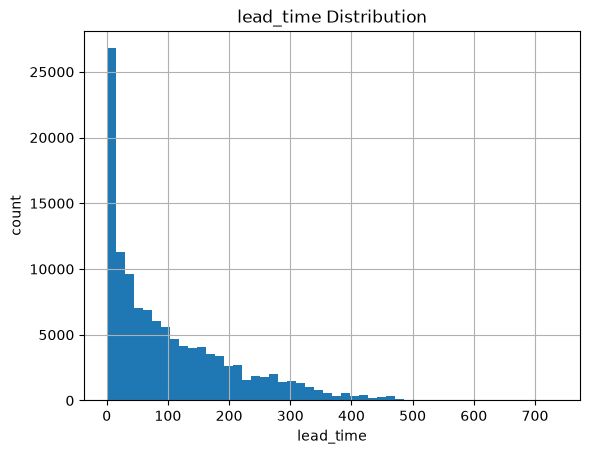

In [53]:
hotel_raw['lead_time'].hist(bins=50)
plt.title('lead_time Distribution')
plt.xlabel('lead_time')
plt.ylabel('count')
plt.show()

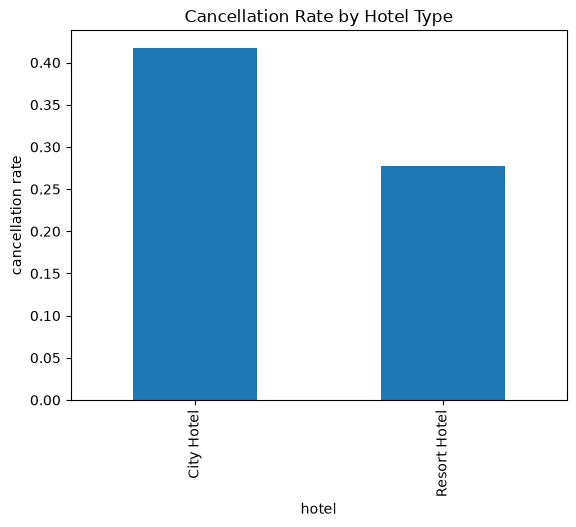

In [54]:
hotel_raw.groupby(by='hotel')['is_canceled'].mean().sort_values(ascending=False).plot(kind='bar')
plt.title('Cancellation Rate by Hotel Type')
plt.ylabel('cancellation rate')
plt.show()

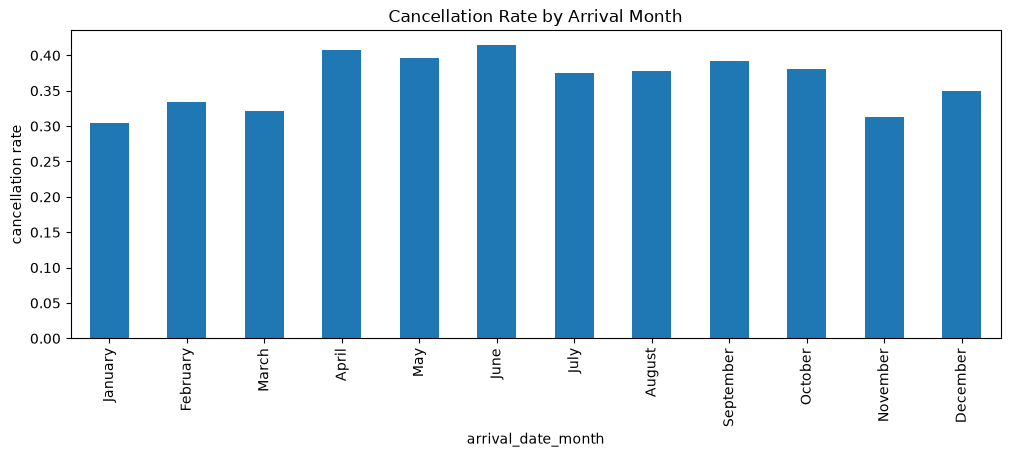

In [55]:
month_order = [
    'January', 'February', 'March', 'April', 'May', 'June',
    'July', 'August', 'September', 'October', 'November', 'December'
]

cancel_by_month = hotel_raw.groupby('arrival_date_month')['is_canceled'].mean().reindex(month_order)
cancel_by_month.plot(kind='bar', figsize=(12, 4))
plt.title('Cancellation Rate by Arrival Month')
plt.ylabel('cancellation rate')
plt.show()

In [56]:
hotel_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  str    
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  str    
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal                       

In [57]:
def add_basic_features(df):
    df = df.copy()
    df['children'] = df['children'].fillna(0)
    # 총 인원수
    df['people'] = df['adults'] + df['children'] + df['babies']
    # 총 숙박일수
    df['total_nights'] = df['stays_in_weekend_nights'] + df['stays_in_week_nights']
    # 월 이름을 계절로 변환
    season_map = {
        'December': 'winter', 'January': 'winter', 'February': 'winter',
        'March': 'spring', 'April': 'spring', 'May': 'spring',
        'June': 'summer', 'July': 'summer', 'August': 'summer',
        'September': 'fall', 'October': 'fall', 'November': 'fall',
    }
    df['arrival_season'] = df['arrival_date_month'].map(season_map)
    # 이전 예약 취소율: 분모가 0이면 이전 기록 없음으로 보고 -1 처리
    previous_total = df['previous_cancellations'] + df['previous_bookings_not_canceled']
    df['previous_cancel_rate'] = np.where(
        previous_total > 0, # 조건
        df['previous_cancellations'] / previous_total, -1 # True, False
    )
    return df

In [58]:
hotel = add_basic_features(hotel_raw)
hotel.info()

<class 'pandas.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 36 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  str    
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  str    
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119390 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal                       

In [59]:
# people 컬럼이 0인 비정상 데이터 제거
hotel = hotel[hotel['people'] > 0].copy()
hotel

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,people,total_nights,arrival_season,previous_cancel_rate
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,Transient,0.00,0,0,Check-Out,2015-07-01,2.0,0,summer,-1.0
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,Transient,0.00,0,0,Check-Out,2015-07-01,2.0,0,summer,-1.0
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,Transient,75.00,0,0,Check-Out,2015-07-02,1.0,1,summer,-1.0
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,Transient,75.00,0,0,Check-Out,2015-07-02,1.0,1,summer,-1.0
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,Transient,98.00,0,1,Check-Out,2015-07-03,2.0,2,summer,-1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119385,City Hotel,0,23,2017,August,35,30,2,5,2,...,Transient,96.14,0,0,Check-Out,2017-09-06,2.0,7,summer,-1.0
119386,City Hotel,0,102,2017,August,35,31,2,5,3,...,Transient,225.43,0,2,Check-Out,2017-09-07,3.0,7,summer,-1.0
119387,City Hotel,0,34,2017,August,35,31,2,5,2,...,Transient,157.71,0,4,Check-Out,2017-09-07,2.0,7,summer,-1.0
119388,City Hotel,0,109,2017,August,35,31,2,5,2,...,Transient,104.40,0,0,Check-Out,2017-09-07,2.0,7,summer,-1.0


In [60]:
# 실제 예약시점 예측에 부적절하거나 누수 위험이 큰 칼럼 제거
leakage_or_post_booking_cols = [
    'reservation_status',       # is_canceled와 직접적으로 연결되는 누수 컬럼
    'reservation_status_date',  # 취소/체크아웃 결과 이후의 날짜 정보
    'assigned_room_type',       # 예약 시점에는 모를 수 있는 사후 배정 정보
]

# 파생 변수 생성으로 인해 중복되는 칼럼 제거
redundant_cols = [
    'adults', 'children', 'babies',
    'stays_in_weekend_nights', 'stays_in_week_nights',
    'arrival_date_month',
    'previous_cancellations', 'previous_bookings_not_canceled',
]

cols_to_drop = [col for col in leakage_or_post_booking_cols + redundant_cols if col in hotel.columns]
hotel = hotel.drop(columns=cols_to_drop)
hotel.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,meal,country,market_segment,distribution_channel,...,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,people,total_nights,arrival_season,previous_cancel_rate
0,Resort Hotel,0,342,2015,27,1,BB,PRT,Direct,Direct,...,NaN,0,Transient,0.0,0,0,2.0,0,summer,-1.0
1,Resort Hotel,0,737,2015,27,1,BB,PRT,Direct,Direct,...,NaN,0,Transient,0.0,0,0,2.0,0,summer,-1.0
2,Resort Hotel,0,7,2015,27,1,BB,GBR,Direct,Direct,...,NaN,0,Transient,75.0,0,0,1.0,1,summer,-1.0
3,Resort Hotel,0,13,2015,27,1,BB,GBR,Corporate,Corporate,...,NaN,0,Transient,75.0,0,0,1.0,1,summer,-1.0
4,Resort Hotel,0,14,2015,27,1,BB,GBR,Online TA,TA/TO,...,NaN,0,Transient,98.0,0,1,2.0,2,summer,-1.0


In [61]:
X = hotel.drop(columns=['is_canceled'])
y = hotel['is_canceled']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2026, stratify=y)

In [62]:
print(X_train.shape, X_test.shape)
print(y_train.value_counts(normalize=True).round(3), y_test.value_counts(normalize=True).round(3))

(95368, 24) (23842, 24)
is_canceled
0    0.629
1    0.371
Name: proportion, dtype: float64 is_canceled
0    0.629
1    0.371
Name: proportion, dtype: float64


In [63]:
numerical_features = X_train.select_dtypes(include='number').columns.tolist()
categorical_features = X_train.select_dtypes(exclude='number').columns.tolist()

print('수치형 컬럼 수:', len(numerical_features))
print(numerical_features)
print('범주형 컬럼 수:', len(categorical_features))
print(categorical_features)

수치형 컬럼 수: 15
['lead_time', 'arrival_date_year', 'arrival_date_week_number', 'arrival_date_day_of_month', 'is_repeated_guest', 'booking_changes', 'agent', 'company', 'days_in_waiting_list', 'adr', 'required_car_parking_spaces', 'total_of_special_requests', 'people', 'total_nights', 'previous_cancel_rate']
범주형 컬럼 수: 9
['hotel', 'meal', 'country', 'market_segment', 'distribution_channel', 'reserved_room_type', 'deposit_type', 'customer_type', 'arrival_season']


In [64]:
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore')),
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features),
    ],
    remainder='drop'
)

# **3. LogisticRegression**

사이킷런의 LogisticRegression은 **이진 분류(Binary Classification)와 다중 분류(Multiclass Classification) 문제를 해결하기 위한 머신러닝 알고리즘**이다. 로지스틱 회귀는 선형 모델로, 입력 데이터에 대한 선형 결합을 통해 확률을 예측하고, 이 확률을 **로지스틱 함수(시그모이드 함수)를 사용**해 이진 또는 다중 클래스에 대한 예측을 수행한다. 사이킷런의 LogisticRegression은 과적합을 방지하기 위한 규제(Regularization) 기법(penalty)을 지원한다. 또한, 반복 최적화의 최대 횟수를 max_iter로 설정할 수 있으며, 모델의 성능 평가는 정확도, ROC-AUC 등 다양한 지표를 통해 수행할 수 있다. 이 모델은 특히 해석 가능성이 높고, 계산이 효율적이며, 선형적으로 구분 가능한 데이터셋에서 뛰어난 성능을 발휘한다.

### ※ 규제
규제(Regularization)는 **머신러닝 모델이 과적합(Overfitting) 되는 것을 방지하기 위해 사용되는 기법**이다. 과적합은 모델이 학습 데이터에 지나치게 맞춰져서, 새로운 데이터(테스트 데이터)에는 제대로 일반화하지 못하는 현상이다. 규제는 모델의 복잡도를 줄이고, 불필요한 가중치(Weights)를 작게 만들어 과적합을 방지한다.
![규제](.\images\규제.png)

### ※ 다중공선성
다중공선성(Multicollinearity)은 회귀 분석에서 **독립 변수들(설명 변수) 간에 강한 상관관계가 존재하는 현상을 의미**한다. 이러한 상관관계가 높으면 각 독립 변수가 종속 변수에 미치는 개별적인 영향을 정확하게 추정하기 어려워지며, 회귀 계수의 추정치가 불안정해져 작은 데이터 변화에도 크게 변할 수 있다. 이는 모델의 예측 성능 저하와 해석의 신뢰성 감소로 이어질 수 있으므로, 다중공선성이 높은 변수를 식별하고 제거하거나 조정하는 것이 중요하다.

### ※ corr() 함수
corr() 함수는 데이터프레임의 숫자형 열 간의 상관관계를 계산하는 데 사용된다. 상관관계는 두 변수 간의 선형 관계를 나타내며, 주로 -1에서 1 사이의 값으로 표현된다.
- corr()는 Pearson 상관계수를 기본으로 사용한다.
- 숫자형 열만 상관관계 분석에 포함된다.
- 높은 상관관계(>|0.5|): 강한 관계
- 낮은 상관관계(<|0.2|): 약한 관계
corr()를 사용하여 높은 상관관계를 가진 컬럼을 식별하고 제거할지 여부를 판단할 수 있다. 특히, 다중공선성(multicollinearity) 문제가 발생할 경우 머신러닝 모델의 성능이 저하될 수 있으므로, 상관관계가 높은 컬럼을 적절히 제거하는 것이 중요하다.

# **4. 혼동 행렬**

혼동 행렬(Confusion Matrix)은 분류 모델의 성능을 평가하기 위해 사용되는 도구로, 예측 결과와 실제 레이블 간의 관계를 요약하여 나타낸 행렬이다. 이 행렬은 이진 분류 문제에서 네 가지 값으로 구성된다. **True Positive (TP), True Negative (TN), False Positive (FP), False Negative (FN).** TP와 TN은 모델이 올바르게 예측한 경우를 나타내며, FP와 FN은 모델이 잘못 예측한 경우를 나타낸다. 이를 통해 분류 모델의 정확도(Accuracy), 정밀도(Precision), 재현율(Recall), F1 점수와 같은 다양한 성능 지표를 계산할 수 있다. 혼동 행렬은 특히 클래스 간 불균형이 있는 데이터에서 모델의 예측 성능을 구체적으로 분석할 때 유용하다
- 예시) 한 클래스의 확률이 90% 이상일 경우 찍어서 맞춰도 좋은 정확도를 가진 모델이라고 평가할 수 있는 경우

![혼동행렬](./images/혼동행렬.png)

- True Positive (TP)
    - 실제값이 양성이고, 모델도 양성으로 올바르게 예측한 경우
    - 예시) 실제로 스팸 메일이고, 모델이 스팸 메일로 예측
- True Negative (TN)
    - 실제값이 음성이고, 모델도 음성으로 올바르게 예측한 경우
    - 예시) 실제로 정상 메일이고, 모델이 정상 메일로 예측
- False Positive (FP)
    - 실제값은 음성이지만, 모델이 양성으로 잘못 예측한 경우
    - 예시) 정상 메일을 스팸으로 잘못 예측
- False Negative (FN)
    - 실제값은 양성이지만, 모델이 음성으로 잘못 예측한 경우
    - 예시) 스팸 메일을 정상 메일로 잘못 예측

### **※ 혼동 행렬로 계산할 수 있는 지표**
![평가지표](./images/평가지표.png)

### **※ ROC AUC Score**
ROC AUC Score(Receiver Operating Characteristic - Area Under the Curve)는 이진 분류 모델의 성능을 평가하는 지표로, 분류기의 예측 능력을 직관적으로 나타낸다. **ROC 곡선은 FPR(거짓 양성 비율)과 TPR(참 양성 비율)을 축으로 하여 다양한 임계값에서 모델의 성능을 시각화한 곡선**이다. **AUC(Area Under the Curve)는 이 곡선 아래의 면적을 나타내며, 값이 1에 가까울수록 완벽한 분류 성능을 의미하고, 0.5에 가까울수록 랜덤 추측에 가까운 성능을 나타낸다.** 따라서 ROC AUC Score는 모델의 분류 성능이 얼마나 좋은지를 평가하는 데 중요한 역할을 한다.

### ※ ROC Curve
ROC 곡선은 이진 분류 모델의 성능을 평가하기 위해 사용하는 곡선으로, 모델의 민감도(참 양성 비율, TPR)와 특이도(참 음성 비율, TNR)의 반대인 거짓 양성 비율(FPR)의 관계를 시각화한 그래프이다.

![ROC Curve](./images/ROC.png)

### ※ AUC (Area Under the Curve)
AUC는 ROC 곡선 아래의 면적을 나타내며, 이진 분류기의 성능을 하나의 숫자로 나타내는 지표이다. AUC는 다음을 의미한다:
- AUC = 1: 완벽한 분류기
- AUC = 0.5: 랜덤 추측 수준
- AUC < 0.5: 모델 성능이 무작위 추측보다 나쁨
수학적으로 AUC는 양성 클래스와 음성 클래스의 예측 점수를 비교해 양성 클래스가 더 높은 점수를 받을 확률을 나타낸다.

In [65]:
from sklearn.metrics import(
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    RocCurveDisplay
)

In [75]:
models = {
    'LogisticRegression': LogisticRegression(max_iter=2000, class_weight='balanced', random_state=2026),
    'RandomForestClassifier': RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=2026, n_jobs=-1)
}

results = []
fitted_models = {}

for name, model in models.items():
    clf = Pipeline([
        ('preprocess', preprocessor),
        ('model', model)
    ])
    clf.fit(X_train, y_train) # 학습
    pred = clf.predict(X_test) # 추론
    if hasattr(clf.named_steps['model'], 'predict_proba'): # hasattr: 객체가 특정 이름의 속성이나 메서드를 가지고 있는지 검사
        proba = clf.predict_proba(X_test)[:, 1] # test 데이터가 class=1;is_canceled=True에 속하는 확률을 가져옴
        auc = roc_auc_score(y_test, proba)
    else:
        proba = None
        auc =  np.nan
    results.append({
        'model': name,
        'accuracy': accuracy_score(y_test, pred),
        'precision': precision_score(y_test, pred, zero_division=0),
        'recall': recall_score(y_test, pred, zero_division=0),
        'f1': f1_score(y_test, pred, zero_division=0),
        'roc_auc': auc
    })
    fitted_models[name] = clf

result_df = pd.DataFrame(results).sort_values('roc_auc', ascending=False)
result_df

,model,accuracy,precision,recall,f1,roc_auc
1,RandomForestClassifier,0.891788,0.856249,0.851018,0.853625,0.957632
0,LogisticRegression,0.802156,0.718727,0.766290,0.741747,0.889994


### 가장 좋은 모델 상세 평가
- 사용 모델
    - LogisticRegression: 선형 분류 모델, 빠르고 해석이 비교적 쉬움
    - RandomForestClassifier: 여러 결정 모델을 묶어서 예측하는 앙상블 모델, 비선형 패턴을 잘 잡을 수 있음
- 평가지표 의미
    - accuracy: 전체 중 맞힌 비율
    - precision: 취소라고 예측한 것 중 실제 취소인 비율
    - recall: 실제 취소 중 모델이 취소라고 잡아낸 비율
    - f1: precision과 recall의 균형 지표
    - roc_auc: 임계값 변화에 따른 전반적인 분류 성능
- 포인트
    - 예약 취소 예측에서는 단순 정확도보다 recall, precision, f1, roc_auc를 함께 봐야함
    - 취소 고객을 최대한 놓치지 않는 것이 중요하면 recall을 더 중요하게 보면 됨
    - 불필요한 객실 확보나 과도한 오버부킹을 줄이는 것이 중요하면 precision도 중요
    - precision_score, recall_score, f1_score에는 zero_division=0을 넣으면 특정 모델이 한 클래스를 전혀 예측하지 않을 때 에러성 경고도 줄일 수 있음

In [87]:
best_model_name = result_df.iloc[0]['model'] # RandomForestClassifier
print('Best model:', best_model_name)
best_model = fitted_models[best_model_name] # RandomForestClassifier의 객체 상태

best_pred = best_model.predict(X_test)
best_proba = best_model.predict_proba(X_test)[:, 1]
print('Confusion matrix')
print(confusion_matrix(y_test, best_pred))
# confusion_matrix 구조
# [[TP FP]
#  [FN TN]]

print('Classification report')
print(classification_report(y_test, best_pred))

print('ROC-AUC:', roc_auc_score(y_test, best_proba))

Best model: RandomForestClassifier
Confusion matrix
[[13739  1263]
 [ 1317  7523]]
Classification report
              precision    recall  f1-score   support

           0       0.91      0.92      0.91     15002
           1       0.86      0.85      0.85      8840

    accuracy                           0.89     23842
   macro avg       0.88      0.88      0.88     23842
weighted avg       0.89      0.89      0.89     23842

ROC-AUC: 0.9576318783438227


### 혼동행렬 해석
- 실제 미취소를 미취소로 예측: 정상 예측
- 실제 미취소를 취소로 예측: 잘못된 취소 예측
- 실제 취소를 미취소로 예측: 놓친 취소 고객
- 실제 취소를 취소로 예측: 정상 예측

> 어떤 오류가 더 비싼지 비즈니스 관점에서 판단해야 함. 호텔 입장에서는 취소 고객을 놓치는 비용과, 취소할 것이라 잘못 판단하는 비용이 다를 수 있음

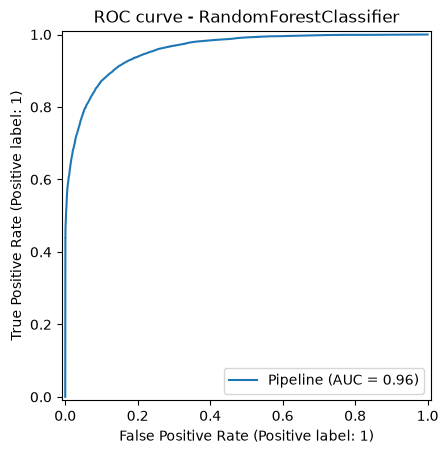

In [89]:
RocCurveDisplay.from_estimator(best_model, X_test, y_test)
plt.title(f'ROC curve - {best_model_name}')
plt.show()

### 예측 임계값 조정
- 기본적으로 분류 모델은 보통 확률이 0.5(임계값) 이상이면 1로 예측
- 실무에서는 0.5가 항상 최선의 임계값이 아님
    - 임계값을 낮추면 취소라고 예측하는 대상이 늘어남
    - 임계값을 높이면 취소 가능성이 높은 대상만 취소라고 예측
- 호텔 예약 취소 예측에서는 임계값 선택이 중요할 수 있음
- 취소 가능 고객에게 사전 확인 문자를 보내는 목적이라면, recall을 높이는 방향이 좋을 수 있음

In [90]:
threshold_table = []

for threshold in np.arange(0.3, 0.71, 0.05):
    threshold_pred = (best_proba >= threshold).astype(int)
    threshold_table.append({
        'threshold': round(threshold, 2),
        'precision': precision_score(y_test, threshold_pred, zero_division=0),
        'recall': recall_score(y_test, threshold_pred, zero_division=0),
        'f1': f1_score(y_test, threshold_pred, zero_division=0),
    })

pd.DataFrame(threshold_table)

,threshold,precision,recall,f1
0,0.30,0.735931,0.937896,0.824729
1,0.35,0.771580,0.920136,0.839335
2,0.40,0.801291,0.898643,0.847179
3,0.45,0.828392,0.878620,0.852767
4,0.50,0.851814,0.855090,0.853449
5,0.55,0.872914,0.828281,0.850012
6,0.60,0.895198,0.797172,0.843346
7,0.65,0.914313,0.761652,0.831029
8,0.70,0.929264,0.726697,0.815591


In [92]:
from sklearn.model_selection import StratifiedKFold, cross_validate

In [95]:
# 교차검증: 데이터를 여러 조각으로 나누고, 학습과 검증을 여러번 반복해서 평균 성능을 보는 방법
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=2026) # n_splits: 정답비율을 유지하면서 데이터를 묶음으로 나눔
cv_model = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('model', RandomForestClassifier(
        n_estimators=300, random_state=2026, n_jobs=-1, class_weight='balanced'
    ))
])
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc'] # cross_validate(): 여러 평가지표를 한 번에 계산
cv_result = cross_validate(cv_model, X, y, cv=cv, scoring=scoring, n_jobs=-1)
cv_summary = pd.DataFrame({
    metric: [cv_result[f'test_{metric}'].mean(), cv_result[f'test_{metric}'].std()] for metric in scoring
}, index=['mean', 'std'])
cv_summary

,accuracy,precision,recall,f1,roc_auc
mean,0.892954,0.858519,0.851671,0.855068,0.959789
std,0.002467,0.005041,0.004076,0.003194,0.000977


### 교차검증으로 모델 안정성 확인
- 평균 성능이 높고 표준편차가 작으면 비교적 안정적인 모델
- 표준편차가 크면 데이터 분할에 따라 성능이 많이 흔들린다는 뜻
- 시간 흐름이 중요한 예약 데이터에서는 StratifiedKFold 대신 시간 기준 검증을 고려해야 함